# 00 — Deep-notched forward isotropic

This notebook runs one `deep_notched` training with default config values, forcing only:

1. `task.type = "forward"`
2. `problem.material.law = "isotropic"`

Then it plots the final predicted fields.

In [1]:
from pathlib import Path
import importlib

import matplotlib as mpl
import matplotlib.pyplot as plt

from phd.config import load_config
import phd.models.cm.deep_notched as dn
from phd.plot import book_config, get_current_config as plt_cfg

# Ensure notebook uses latest local edits in deep_notched.py
dn = importlib.reload(dn)

book_config.set_as_current()
plot_cfg = plt_cfg()
page_width = plot_cfg.page_width if plot_cfg is not None else 7.0

save_fig = False
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "IV_MaterialCharacterization" / "02_deep_notched"
IMAGE_DIR = CHAPTER_DIR / "images"
PDF_DIR = IMAGE_DIR / "pdf"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PDF_DIR.mkdir(parents=True, exist_ok=True)

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



In [20]:
def build_forward_isotropic_cfg(seed: int = 0):
    cfg = load_config("deep_notched")

    cfg.seed = seed
    cfg.task.type = "forward"
    cfg.problem.material.law = "isotropic"

    cfg.model.net_type = "SPINN"
    cfg.model.formulation = "mixed"
    cfg.model.architecture.n_hidden = 3
    cfg.model.architecture.width = 32
    cfg.model.architecture.rank = 32
    cfg.model.architecture.activations = "sin"
    # cfg.model.architecture.mlp_type = "modified_mlp"
    cfg.model.fourier_features.enabled = True
    cfg.model.fourier_features.n_features = 128

    cfg.training.n_iter = 20000
    cfg.training.lr = 1e-3
    # cfg.training.lr_decay = ["warmup cosine", 1e-4, 1e-3, 1000, 30000, 1e-4]
    cfg.training.log_every = 250
    cfg.training.num_domain = 150 ** 2
    cfg.training.coord_normalization = True
    cfg.training.self_attention.enabled = True
    cfg.training.self_attention.share_weights = False
    cfg.training.loss_weights = [1.0]*8 + [1e1]*2
    cfg.training.loss_normalization.scheme = "grad_norm"
    cfg.training.loss_normalization.n_warmup = 100

    cfg.problem.bc.displacement_bc = True
    cfg.problem.bc.corner_eps = 2/100


    cfg.results.base_dir = str(PROJECT_ROOT / "results")
    cfg.task.measurements.enabled = True

    return cfg

In [21]:
# Run or load
run_mode = "run"  # "run" or "load"
run_name = "forward_isotropic"

if run_mode == "run":
    cfg = build_forward_isotropic_cfg(seed=0)
    results = dn.train(cfg)
    run_dir = dn.save_run_data(results, run_name=run_name, base_dir=cfg.results.base_dir)
elif run_mode == "load":
    results = dn.load_run(run_name, base_dir=PROJECT_ROOT / "results")
    cfg = results["config"]
else:
    raise ValueError("run_mode must be 'run' or 'load'.")

Set the default automatic differentiation to forward mode.
Compiling model...
'compile' took 0.115916 s

Training model...



KeyboardInterrupt: 

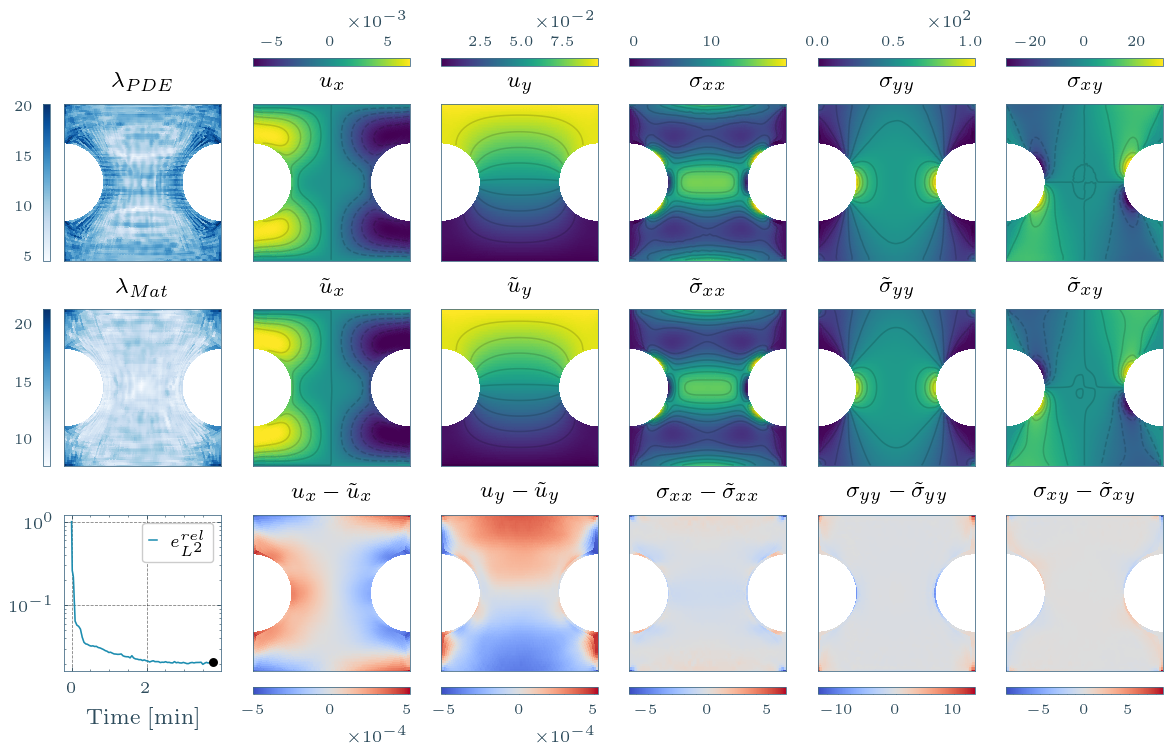

In [19]:
# Plot and save results
fig, artists = dn.plot_results(
    results,
    iteration=-1,
    step_type="time",
    time_unit="min",
    fields=["Ux", "Uy", "Sxx", "Syy", "Sxy"],
    plot_contours=True,
    dpi=200,
    show_metrics=True,
    show_residual=True,
    show_iter=False,
    metrics=["L2 Error"],
    side_panel="weights",
)